# Swiss Housing Price Analysis — Walkthrough

End-to-end mirror of the pipeline in `src/pipeline.py`:

**collect → scrape → clean → enrich (LLM) → validate → SQLite → statistics → insights → visualize**

**Research question.** Which factors (size, rooms, location, features) significantly influence Swiss housing rents, and are those relationships statistically significant?

Dataset: ~200 listings from Flatfox, Canton Zurich only, full apartments only (no WGs / single rooms / temporary).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

import pandas as pd
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

## 1. Collect Zurich-canton listings (Flatfox API → JSON cache)

In [2]:
from src.pipeline import load_or_collect_zurich
raw = load_or_collect_zurich(target=200)
print(f'raw listings: {len(raw)}')
pd.DataFrame(raw[:3])

[pipeline] cached: 200 Zurich listings from zurich_apartments.json
raw listings: 200


,title,rent_price,rooms,living_space_m2,city,zip_code,listing_url
0,"Haldenstr. 10, 8420 Fehraltorf - CHF 2’870 inc...",2870,4.5,69,Fehraltorf,8320,https://flatfox.ch/en/flat/haldenstr-10-8320-f...
1,"Loostrasse 7, 8803 Rüschlikon - CHF 6’600 incl...",6600,3.5,170,Rüschlikon,8803,https://flatfox.ch/en/flat/loostrasse-7-8803-r...
2,"Rieterstrasse 79, 8002 Zürich - CHF 5’030 incl...",5040,3.5,70,Zürich,8002,https://flatfox.ch/en/flat/rieterstrasse-79-80...


## 2. Reshape & regex-clean

In [3]:
from src.pipeline import _to_cleaner_shape
from src.cleaning import clean_records

raw_rows = [_to_cleaner_shape(r) for r in raw]
cleaned = clean_records(raw_rows)
print(f'cleaned: {len(cleaned)} (dropped {len(raw_rows) - len(cleaned)} with missing price/size)')
pd.DataFrame(cleaned[:3])

cleaned: 200 (dropped 0 with missing price/size)


,title,price,size,rooms,city,canton,zip_code,features,balcony,parking,description,listing_url
0,"Haldenstr. 10, 8420 Fehraltorf - CHF 2’870 inc...",2870,69.0,4.5,Fehraltorf,ZH,8320,[],0,0,,https://flatfox.ch/en/flat/haldenstr-10-8320-f...
1,"Loostrasse 7, 8803 Rüschlikon - CHF 6’600 incl...",6600,170.0,3.5,Rüschlikon,ZH,8803,[],0,0,,https://flatfox.ch/en/flat/loostrasse-7-8803-r...
2,"Rieterstrasse 79, 8002 Zürich - CHF 5’030 incl...",5040,70.0,3.5,Zürich,ZH,8002,[],0,0,,https://flatfox.ch/en/flat/rieterstrasse-79-80...


## 3. LLM enrichment (OpenAI gpt-4o-mini; regex fallback if no key)

Each apartment description goes through `LLMProcessor.extract_features`, which returns boolean flags for `balcony`, `parking`, `furnished`. Results are cached in `data/llm_cache.sqlite`.

In [4]:
from src.llm_helper import LLMProcessor, enrich_records
processor = LLMProcessor()
enriched = enrich_records(cleaned, processor)
print(f'mode: {processor.mode}  '
      f'openai={processor.calls_openai}  cache={processor.calls_cache}  '
      f'fallback={processor.calls_fallback}')
{k: enriched[0][k] for k in ('title', 'llm_balcony', 'llm_parking', 'llm_furnished')}

[llm] initialised: OpenAI client ready (model=gpt-4o-mini)
mode: openai-ready  openai=0  cache=0  fallback=0


{'title': 'Haldenstr. 10, 8420 Fehraltorf - CHF 2’870 incl. utilities per month',
 'llm_balcony': 0,
 'llm_parking': 0,
 'llm_furnished': 0}

## 4. Pandas + CHF/m² + price categories

In [5]:
from src.analysis import records_to_dataframe
df = records_to_dataframe(enriched)
df['chf_per_m2'] = (df['price'] / df['size']).round(2)
df.head()

,title,price,size,rooms,city,canton,zip_code,features,balcony,parking,description,listing_url,llm_balcony,llm_parking,llm_furnished,chf_per_m2
0,"Haldenstr. 10, 8420 Fehraltorf - CHF 2’870 inc...",2870,69.0,4.5,Fehraltorf,ZH,8320,[],0,0,,https://flatfox.ch/en/flat/haldenstr-10-8320-f...,0,0,0,41.59
1,"Loostrasse 7, 8803 Rüschlikon - CHF 6’600 incl...",6600,170.0,3.5,Rüschlikon,ZH,8803,[],0,0,,https://flatfox.ch/en/flat/loostrasse-7-8803-r...,0,0,0,38.82
2,"Rieterstrasse 79, 8002 Zürich - CHF 5’030 incl...",5040,70.0,3.5,Zürich,ZH,8002,[],0,0,,https://flatfox.ch/en/flat/rieterstrasse-79-80...,0,0,0,72.00
3,"Forenackerstrasse 6, 8236 Langwiesen - CHF 2’3...",2460,130.0,3.5,Langwiesen,ZH,8246,[],0,0,,https://flatfox.ch/en/flat/forenackerstrasse-6...,0,0,0,18.92
4,"Asylstrasse 71, 8042 Zürich - CHF 6’140 incl. ...",6140,180.0,4.5,Zürich,ZH,8032,[],0,0,,https://flatfox.ch/en/flat/asylstrasse-71-8032...,0,0,0,34.11


## 5. Data quality validation

The validator drops duplicates, impossible values, CHF/m² outside [10, 200], and statistical outliers (Tukey k=3). The report below feeds the dashboard's "Data quality" tab.

In [6]:
from src.data_quality import validate, extended_summary, price_categories
df_clean, quality = validate(df)
df_clean = price_categories(df_clean)
print('quality report:')
for k, v in quality.as_dict().items():
    print(f'  {k:>26}: {v}')
print()
extended_summary(df_clean)

quality report:
                     n_input: 200
                    n_output: 199
                n_duplicates: 0
          n_missing_required: 0
          n_impossible_price: 0
           n_impossible_size: 0
          n_impossible_rooms: 0
       n_chf_per_m2_outliers: 1
      n_statistical_outliers: 0
              retention_rate: 0.995



{'n_listings': 199,
 'n_cities': 56,
 'mean_price': 4092.5125628140704,
 'median_price': 3830.0,
 'std_price': 1551.4918589788804,
 'min_price': 1500.0,
 'max_price': 9820.0,
 'iqr_price': 2050.0,
 'mean_size': 94.9748743718593,
 'median_size': 79.0,
 'mean_rooms': 3.6608040201005023,
 'median_rooms': 3.5,
 'mean_chf_per_m2': 53.253216080402005,
 'median_chf_per_m2': 46.0,
 'mean_price_balcony': None,
 'mean_price_no_balcony': 4092.5125628140704,
 'mean_price_parking': None,
 'mean_price_no_parking': 4092.5125628140704}

## 6. SQLite + SQL queries (incl. window functions)

In [7]:
from src.database import HousingDatabase

df_for_db = df_clean.copy()
df_for_db['features'] = df_for_db['features'].apply(
    lambda xs: ','.join(xs) if isinstance(xs, list) else xs)

with HousingDatabase() as db:
    db.save(df_for_db)
    print('--- Average price by rooms ---')
    print(db.avg_price_by_rooms())
    print('\n--- City ranking (premium vs market) ---')
    print(db.city_ranking_with_premium(min_n=3).head(10))
    print('\n--- Price tiers via NTILE window function ---')
    print(db.price_distribution_by_category())
    print('\n--- Feature premium ---')
    print(db.feature_premium())

--- Average price by rooms ---
   rooms  avg_price  avg_chf_per_m2   n
0    2.0     3732.0          105.26  17
1    2.5     3356.0           73.71  10
2    3.0     4156.0           75.28  19
3    3.5     4242.0           45.12  73
4    4.0     3324.0           43.08  12
5    4.5     4175.0           42.16  66
6    5.5     4690.0           18.76   1
7    6.5     8610.0           28.70   1

--- City ranking (premium vs market) ---
   rank          city   n  avg_price  avg_chf_per_m2  premium_vs_market_pct
0     1        Zürich  91     4655.0           71.68                   62.4
1     2    Fehraltorf   3     2363.0           57.82                   31.0
2     3        Kloten   6     3293.0           52.13                   18.1
3     4     Männedorf   4     3238.0           48.85                   10.7
4     5    Rüschlikon   4     5790.0           46.54                    5.4
5     6      Zollikon   4     6823.0           45.88                    3.9
6     7  Zollikerberg   5     3394.

## 7. Statistical tests with effect sizes

For each test we report the statistic, p-value, effect size, plain-language interpretation, the assumptions, and *why* we chose that test.

In [8]:
from src.statistics import run_all_tests
for t in run_all_tests(df_clean):
    print(f"[{t.name}]  stat={t.statistic:.3f}  p={t.p_value:.4f}  sig={t.significant}")
    if t.effect_size_label:
        print(f"    effect: {t.effect_size_label}")
    print(f"    → {t.interpretation}")
    print()

[shapiro_price]  stat=0.941  p=0.0000  sig=True
    → W = 0.941, p < 0.001 (very strong evidence against the null hypothesis). Prices are NOT consistent with a normal distribution — this justifies using non-parametric tests (Mann-Whitney) alongside the parametric ones.

[pearson_size_price]  stat=0.474  p=0.0000  sig=True
    effect: R² = 0.225 — size explains 22.5% of price variance
    → r = 0.474 (moderate positive linear relationship). p < 0.001 (very strong evidence against the null hypothesis). Each additional m² of living space is associated with higher rent.

[spearman_rooms_price]  stat=0.088  p=0.2143  sig=False
    effect: ρ² = 0.008 (rank-based variance share)
    → ρ = 0.088 (negligible monotonic relationship). p = 0.2143 (not statistically significant at α = 0.05). Rooms correlate with price but more weakly than size — apartments with the same room count vary widely in m², which dilutes the signal.

[pearson_size_chf_per_m2]  stat=-0.580  p=0.0000  sig=True
    effect: R²

## 8. Business insights (auto-generated)

In [9]:
from src.insights import generate
for ins in generate(df_clean):
    print(f"• [{ins.confidence:>6}] {ins.headline}")
    print(f"           {ins.metric}: {ins.metric_value}")
    print(f"           {ins.detail[:200]}…")
    print()

• [  high] Living space is the single strongest price driver (r = 0.47).
           R² (size vs price): 0.22
           Pearson correlation between m² and rent is 0.474 (p = 1.546e-12), meaning size alone explains roughly 22% of price variation in the sample.…

• [   low] Room count is a noisy proxy for price compared to size.
           r (rooms vs price): 0.13
           Rooms correlate with rent at r = 0.13 (p = 0.07436) — much weaker than the size signal. Two 3.5-room apartments can differ by 50+ m², explaining the looser fit.…

• [  high] Small apartments charge a per-m² premium (size ↔ CHF/m² is inverse).
           r (size vs CHF/m²): -0.58
           r = -0.58 (p = 2.709e-19). The smallest 25% of the sample average CHF 86/m², versus CHF 30/m² for the largest 25%.…

• [  high] Zürich is 2.8× more expensive per m² than Langwiesen.
           Zürich vs Langwiesen: 2.8× CHF/m²
           Among cities with at least 3 listings, Zürich averages CHF 72/m² versus CHF 26/m² in Langwiesen

## 9. Visualizations — static (matplotlib) and interactive (Plotly)

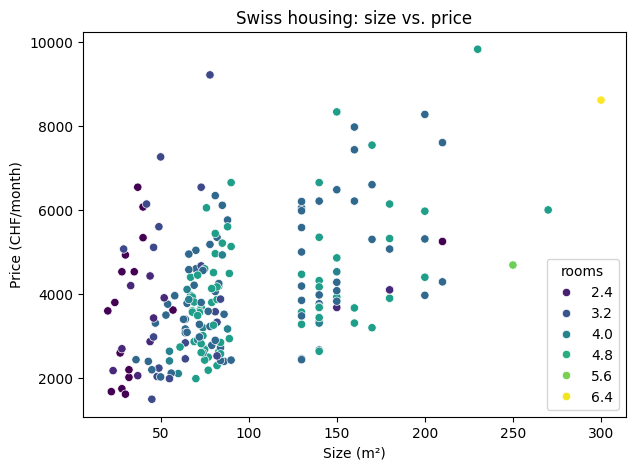

In [10]:
from src.visualization import scatter_size_price, boxplot_rooms_price, barplot_avg_price_by_city
scatter_size_price(df_clean);

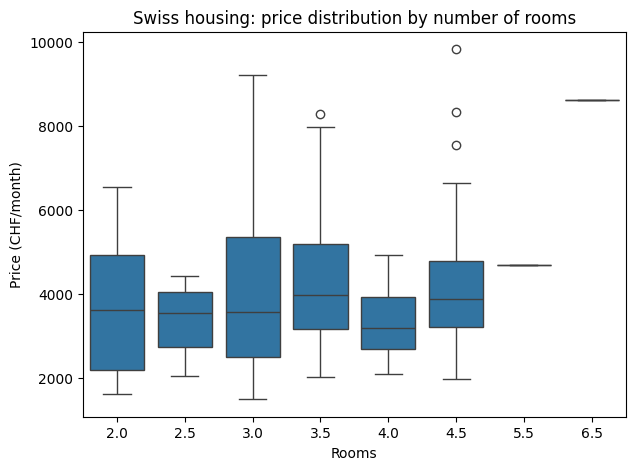

In [11]:
boxplot_rooms_price(df_clean);

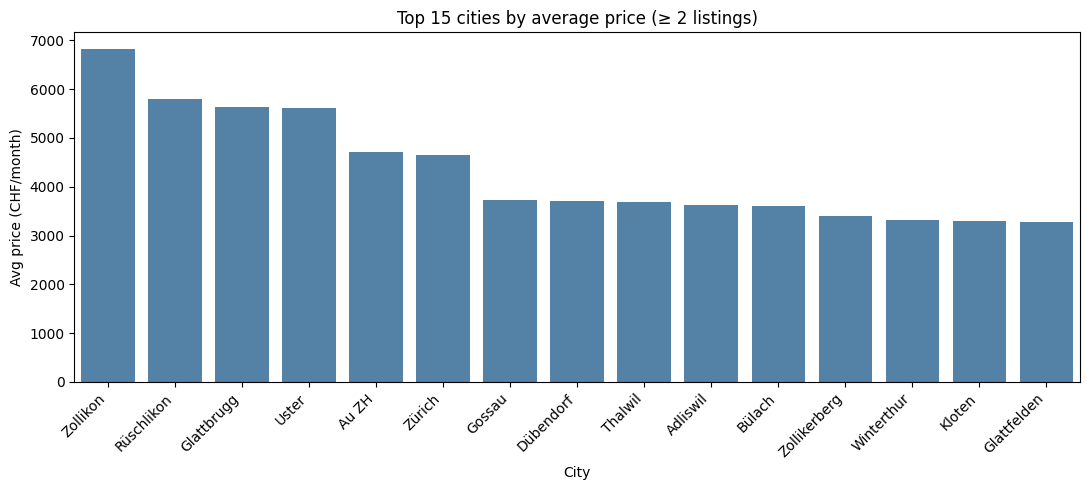

In [12]:
barplot_avg_price_by_city(df_clean);

In [13]:
from src.visualization import (
    plotly_scatter_size_price, plotly_chf_per_m2_histogram,
    plotly_correlation_heatmap, plotly_geographic_map,
)
plotly_scatter_size_price(df_clean)

In [14]:
plotly_chf_per_m2_histogram(df_clean)

In [15]:
plotly_correlation_heatmap(df_clean)

In [16]:
plotly_geographic_map(df_clean)

## 10. Environment info

In [17]:
import os, platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2026-05-24 20:52:03
Python Version: 3.14.0
-----------------------------------
